In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False
)
print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 60000
Test: 10000


In [10]:
total = len(train_loader.dataset) + len(test_loader.dataset)
print("Total:", total)
num_classes = torch.max(train_dataset.targets).item() + 1
print("Number of classes:", num_classes)
image_shape = train_dataset.data[0].shape
print("Image shape:", image_shape)
pixel_range = (train_dataset.data.min().item(), train_dataset.data.max().item())
print("Pixel range:", pixel_range)
pixel_mean = train_dataset.data.float().mean().item()
print("Pixel mean:", pixel_mean)
pixel_std = train_dataset.data.float().std().item()
print("Pixel std:", pixel_std)
pixel_min = train_dataset.data.float().min().item()
print("Pixel min:", pixel_min)
pixel_max = train_dataset.data.float().max().item()
print("Pixel max:", pixel_max)


Total: 70000
Number of classes: 10
Image shape: torch.Size([28, 28])
Pixel range: (0, 255)
Pixel mean: 33.31842041015625
Pixel std: 78.56748962402344
Pixel min: 0.0
Pixel max: 255.0


In [12]:
print("Class distribution:")
for i in range(num_classes):
    class_count = (train_dataset.targets == i).sum().item()
    print(f"Class {i}: {class_count} samples")

Class distribution:
Class 0: 5923 samples
Class 1: 6742 samples
Class 2: 5958 samples
Class 3: 6131 samples
Class 4: 5842 samples
Class 5: 5421 samples
Class 6: 5918 samples
Class 7: 6265 samples
Class 8: 5851 samples
Class 9: 5949 samples


In [14]:
print(f"Pixel value distribution: {pixel_range}")
print(f"Pixel mean: {pixel_mean:.4f}, Pixel std: {pixel_std:.4f}")
print(f"Pixel min: {pixel_min}, Pixel max: {pixel_max}")

Pixel value distribution: (0, 255)
Pixel mean: 33.3184, Pixel std: 78.5675
Pixel min: 0.0, Pixel max: 255.0


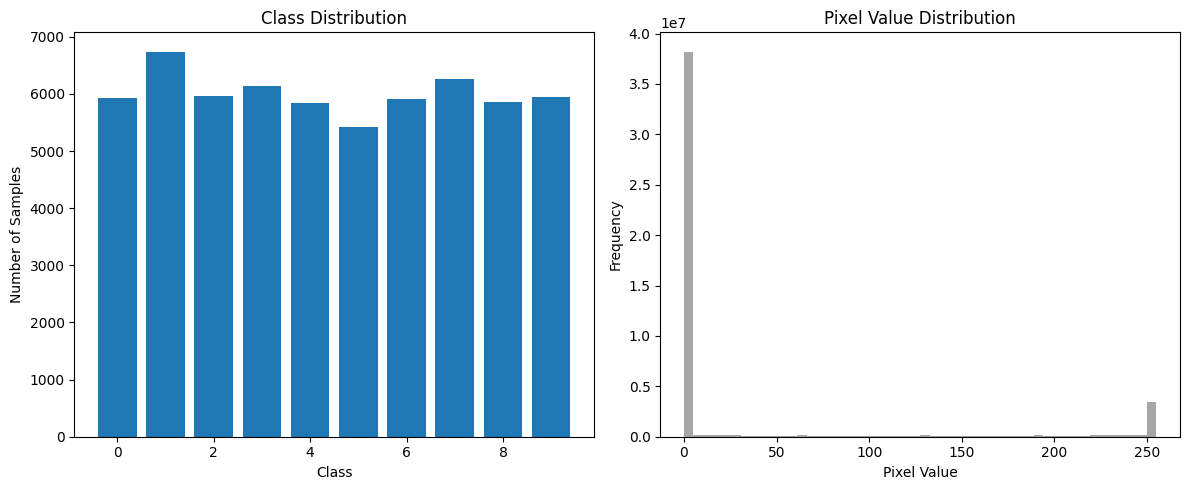

In [15]:
# Plot class distribution and histogram
import numpy as np
class_counts = [ (train_dataset.targets == i).sum().item() for i in range
(num_classes)]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(num_classes), class_counts)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.subplot(1, 2, 2)
plt.hist(train_dataset.data.numpy().flatten(), bins=50, color='gray', alpha=0.7)
plt.title("Pixel Value Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()